Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 36.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.58MB/s]


[Sigmoid] Epoch 1/5 - Loss: 0.3059, Accuracy: 0.8676
[Sigmoid] Epoch 2/5 - Loss: 0.1048, Accuracy: 0.9462
[Sigmoid] Epoch 3/5 - Loss: 0.1024, Accuracy: 0.9627
[Sigmoid] Epoch 4/5 - Loss: 0.0670, Accuracy: 0.9712
[Sigmoid] Epoch 5/5 - Loss: 0.1572, Accuracy: 0.9763
Training time (Sigmoid): 93.37 seconds

[Tanh] Epoch 1/5 - Loss: 0.4676, Accuracy: 0.9062
[Tanh] Epoch 2/5 - Loss: 0.3476, Accuracy: 0.9532
[Tanh] Epoch 3/5 - Loss: 0.2747, Accuracy: 0.9610
[Tanh] Epoch 4/5 - Loss: 0.0060, Accuracy: 0.9657
[Tanh] Epoch 5/5 - Loss: 0.0621, Accuracy: 0.9687
Training time (Tanh): 96.90 seconds

[ReLU] Epoch 1/5 - Loss: 0.0659, Accuracy: 0.8961
[ReLU] Epoch 2/5 - Loss: 0.0288, Accuracy: 0.9529
[ReLU] Epoch 3/5 - Loss: 0.0257, Accuracy: 0.9661
[ReLU] Epoch 4/5 - Loss: 0.0766, Accuracy: 0.9718
[ReLU] Epoch 5/5 - Loss: 0.1130, Accuracy: 0.9760
Training time (ReLU): 102.10 seconds



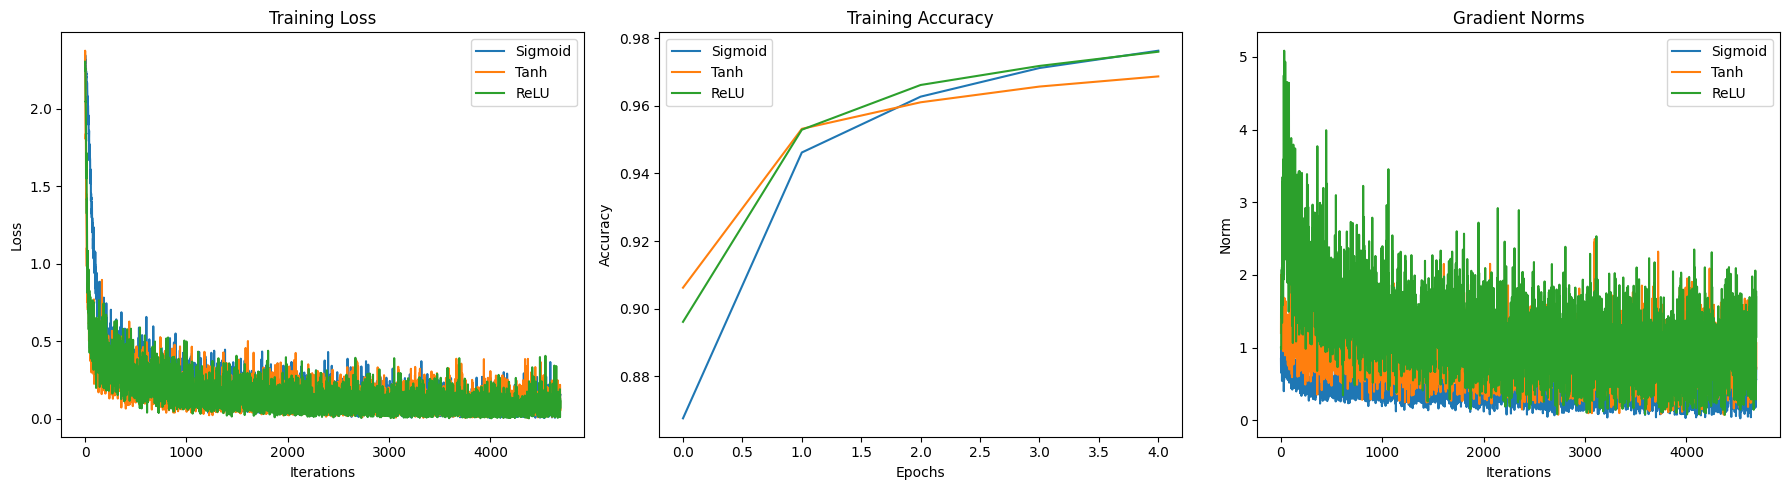

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------------------
# 🔹 Load Dataset (MNIST)
# -------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)

# -------------------------------------------
# 🔹 Define MLP Model
# -------------------------------------------
class MLP(nn.Module):
    def __init__(self, activation_fn):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.activation = activation_fn

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

# -------------------------------------------
# 🔹 Training Function
# -------------------------------------------
def train_model(activation_name, activation_fn, epochs=5):
    model = MLP(activation_fn).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    loss_list, acc_list, grad_norms = [], [], []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_correct, total_samples = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # Track gradient norm
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            grad_norms.append(total_norm ** 0.5)

            optimizer.step()
            loss_list.append(loss.item())

            # Accuracy calculation
            _, predicted = torch.max(outputs, 1)
            total_samples += labels.size(0)
            total_correct += (predicted == labels).sum().item()

        accuracy = total_correct / total_samples
        acc_list.append(accuracy)
        print(f"[{activation_name}] Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

    total_time = time.time() - start_time
    print(f"Training time ({activation_name}): {total_time:.2f} seconds\n")
    return loss_list, acc_list, grad_norms

# -------------------------------------------
# 🔹 Run Experiments for All Activations
# -------------------------------------------
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU()
}

results = {}
for name, act_fn in activations.items():
    results[name] = train_model(name, act_fn)

# -------------------------------------------
# 🔹 Visualization
# -------------------------------------------
plt.figure(figsize=(18,5))

# Loss curve
plt.subplot(1,3,1)
for name in activations.keys():
    plt.plot(results[name][0], label=name)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()

# Accuracy curve
plt.subplot(1,3,2)
for name in activations.keys():
    plt.plot(results[name][1], label=name)
plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Gradient norms
plt.subplot(1,3,3)
for name in activations.keys():
    plt.plot(results[name][2], label=name)
plt.title("Gradient Norms")
plt.xlabel("Iterations")
plt.ylabel("Norm")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
'''
✅ FULL LINE-BY-LINE EXPLANATION
-------------------------------------------------------
1. Importing Required Libraries
-------------------------------------------------------
import torch


✔ Imports the core PyTorch library for tensors and neural networks.

import torch.nn as nn


✔ Imports PyTorch’s neural network module (contains Linear, ReLU, etc.)

import torch.optim as optim


✔ Contains optimizers (Adam, SGD, etc.)

from torchvision import datasets, transforms


✔ Imports:

datasets → like MNIST, CIFAR, etc.

transforms → image preprocessing functions

from torch.utils.data import DataLoader


✔ Used to load data in batches (mini-batches).

import matplotlib.pyplot as plt


✔ Used for plotting graphs — loss, accuracy, gradient norms.

import time


✔ Used to measure training time.

-------------------------------------------------------
2. Check CUDA (GPU)
-------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


✔ If GPU available → use CUDA
✔ Otherwise → use CPU

print(f"Using device: {device}")


✔ Prints whether training will run on GPU or CPU.

-------------------------------------------------------
3. Load MNIST Dataset
-------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


✔ Converts image to tensor
✔ Normalizes pixel values to range (-1, 1)

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)


✔ Loads MNIST training dataset

test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


✔ Loads MNIST testing dataset

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)


✔ Loads training data in batches of 64
✔ shuffle=True → randomize data each epoch

test_loader = DataLoader(test_data, batch_size=1000, shuffle=False)


✔ Testing data in batch of 1000
✔ No shuffling required

-------------------------------------------------------
4. Define MLP Model
-------------------------------------------------------
class MLP(nn.Module):


✔ Creates a custom neural network class.

def __init__(self, activation_fn):


✔ Constructor — receives activation function dynamically.

super(MLP, self).__init__()


✔ Initializes parent class (nn.Module)

Layers
self.fc1 = nn.Linear(28*28, 256)


✔ First layer: 784 → 256

self.fc2 = nn.Linear(256, 128)


✔ Second layer: 256 → 128

self.fc3 = nn.Linear(128, 10)


✔ Output layer: 128 → 10 classes

self.activation = activation_fn


✔ Stores activation: ReLU / Sigmoid / Tanh

Forward Pass
def forward(self, x):


✔ Defines how data flows through the network.

x = x.view(x.size(0), -1)


✔ Flattens 28×28 → 784

x = self.activation(self.fc1(x))


✔ Hidden Layer 1 + Activation

x = self.activation(self.fc2(x))


✔ Hidden Layer 2 + Activation

x = self.fc3(x)


✔ Output layer (no activation)

return x


✔ Returns logits (raw scores)

-------------------------------------------------------
5. Training Function
-------------------------------------------------------
def train_model(activation_name, activation_fn, epochs=5):


✔ Trains MLP with selected activation function

model = MLP(activation_fn).to(device)


✔ Creates MLP and moves to GPU/CPU

optimizer = optim.Adam(model.parameters(), lr=0.001)


✔ Adam optimizer with learning rate 0.001

criterion = nn.CrossEntropyLoss()


✔ Loss function for classification

Lists for graphs
loss_list, acc_list, grad_norms = [], [], []


✔ Stores loss
✔ Stores accuracy
✔ Stores gradient norms

start_time = time.time()


✔ Start time for training duration

Training Loop
for epoch in range(epochs):


✔ Runs training for given epochs

Switch to training mode
model.train()

total_correct, total_samples = 0, 0


✔ Tracks accuracy

Training per batch
for images, labels in train_loader:


✔ Loop over mini batches

images, labels = images.to(device), labels.to(device)


✔ Move data to GPU/CPU

optimizer.zero_grad()


✔ Clears previous gradients

outputs = model(images)


✔ Forward pass

loss = criterion(outputs, labels)


✔ Compute loss

loss.backward()


✔ Backpropagation (compute gradients)

Compute Gradient Norm
total_norm = 0.0

for p in model.parameters():
    if p.grad is not None:
        param_norm = p.grad.data.norm(2)
        total_norm += param_norm.item() ** 2


✔ Computes L2 norm of gradients
✔ Measures exploding/vanishing gradients

grad_norms.append(total_norm ** 0.5)

optimizer.step()


✔ Update model weights

loss_list.append(loss.item())


✔ Store training loss

Accuracy
_, predicted = torch.max(outputs, 1)


✔ Get predicted class

total_samples += labels.size(0)
total_correct += (predicted == labels).sum().item()


✔ Count correct predictions

Epoch accuracy
accuracy = total_correct / total_samples
acc_list.append(accuracy)

print(f"[{activation_name}] Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")


✔ Prints accuracy and loss

Total time
total_time = time.time() - start_time
print(f"Training time ({activation_name}): {total_time:.2f} seconds\n")

return loss_list, acc_list, grad_norms


✔ Return all stored metrics

-------------------------------------------------------
6. Run Experiments
-------------------------------------------------------
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU()
}


✔ Dictionary of activation functions

results = {}

for name, act_fn in activations.items():
    results[name] = train_model(name, act_fn)


✔ Train 3 models:

Sigmoid

Tanh

ReLU

-------------------------------------------------------
7. Plot Results
-------------------------------------------------------
Plot Loss
plt.subplot(1,3,1)


✔ 1 row, 3 columns → first plot

plt.plot(results[name][0], label=name)


✔ results[name][0] = loss list

Plot Accuracy
plt.subplot(1,3,2)

plt.plot(results[name][1], label=name)


✔ results[name][1] = accuracy

Plot Gradient Norms
plt.subplot(1,3,3)

plt.plot(results[name][2], label=name)


✔ results[name][2] = gradient norms

plt.tight_layout()
plt.show()


✔ Final display of all graphs